# 6.4 PROPERTIES OF THE STATES IN A MARKOV PROCESS

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/drive/1OQYqNRdOL8JlvK8uvQKRk6VnUy2pIi2q?usp=sharing)


Before continuing with our analysis of the long-term behavior of Markov processes, we must define some of the properties of the states that can be occupied by a Markov process. As we will see, the particular patterns with which transitions occur into and out of a state have a great deal to do with the role which that state plays in the eventual behavioral trends of a system.
A state j is reachable from state i if there is a sequence of transitions that begins in state i and ends in state j . This is, $\mathrm{p}^{(\mathrm{n})}{ }_{\mathrm{ij}}>0$ for some n .
An irreducible Markov chain is one in which every state is reachable from every other state. That is, in an irreducible chain, it is not possible for the process to become trapped and thereafter to make transitions only within some subset of the states.
A set of states is said to be closed if no state outside of the set is reachable from any state inside the set. This means that once the system enters any state in the set, it will never leave the set. In an irreducible chain, all the states constitute a closed set and no subset of the states is closed.
A particularly interesting case arises if a closed set contains only one state. This state i is called an absorbing state, and $\mathrm{p}_{\mathrm{ii}}=1$. The system never leaves an absorbing state.
A state $i$ is a transient state if there is a transition out of state $i$ to some other state $j$ from which state i can never be reached again. Thus, whenever a transient state is left, there is a positive probability it will never be occupied again. And therefore, the long-term probability of a system being in a transient state is essentially zero because eventually, the state will be left and never entered again.

A recurrent state is any state that is not transient. In an irreducible finite-state Markov chain, all states are recurrent. A special case of a recurrent state is an absorbing state, from which no other state can be reached.
The various state characteristics just defined can be illustrated by the Markov process whose one-step transition probability matrix is given by:

$$
\mathrm{P}=\left[\begin{array}{cccccc}
1 / 3 & 1 / 3 & 0 & 0 & 0 & 1 / 3 \\
0 & 0 & 9 / 10 & 0 & 0 & 1 / 10 \\
0 & 0 & 1 / 3 & 2 / 3 & 0 & 0 \\
0 & 0 & 1 / 2 & 1 / 4 & 1 / 4 & 0 \\
0 & 0 & 1 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & 0 & 1
\end{array}\right]
$$

and which is illustrated by the transition diagram in Figure 6.3. In this example, state 6 is an absorbing (and therefore recurrent) state because there is only one arc out of state 6, and $\mathrm{p}_{66}=1$. States 1 and 2 are transient because after each state is left, it is never re-entered. In the case of state 2, there is no possible way to return. On the other hand, it is possible for state 1 to recur as the system changes from state 1 directly again to state 1 ; but once a transition is made out of state 1, that state is never entered again. States 3, 4, and 5 are recurrent states.
A state is said to be periodic if it is occupied only at times which differ from one another by multiples of some constant greater than 1. In Figure 6.4a, all three states are periodic with period 2; and in Figure 6.4b, all states are periodic with period 4. In general, the period $t$ of a periodic state $i$ is the smallest integer such that all transition sequences from state i back to itself take some multiple of t steps, and $\mathrm{t}>1$.

![](https://cdn.mathpix.com/cropped/2006c750-dc2a-4c1f-9672-416eca5f2ff4-284.jpg?height=704&width=749&top_left_y=1521&top_left_x=500)

**FIGURE 6.3** <br>
Transition diagram with transient and recurrent states.

![](https://cdn.mathpix.com/cropped/2006c750-dc2a-4c1f-9672-416eca5f2ff4-285.jpg?height=460&width=518&top_left_y=269&top_left_x=617)

**FIGURE 6.4** <br>
(a,b) Periodic states.

If a state can be occupied at any time, then it is said to have period 1, or to be aperiodic. In an irreducible chain, all states are either aperiodic, or are periodic and all have the same period. An irreducible finite-state Markov chain in which all states are aperiodic is called an ergodic Markov chain.
In the limit, as time goes to infinity, the occupancy of periodic states never stabilizes because these states are likely to be occupied at certain times and yet cannot be occupied at other times. Similarly, in the long run, transient states are not of interest because they are eventually left and not re-entered. If we eliminate periodic and transient states from our consideration, and focus on ergodic processes, we find that we can further characterize the limiting behavior of a Markov process. In the following sections, we will describe the calculations for two such behavioral characteristics observed in Markov processes.

In [1]:
import numpy as np
import pandas as pd
!pip install pydtmc
from pydtmc import MarkovChain
from pydtmc.plotting import plot_graph

=== 6.4 State Classification (Figure 6.3, p.262) ===
  recurrent_states:  ['3', '4', '5', '6']
  transient_states:  ['1', '2']
  absorbing_states:  ['6']
  is_irreducible:    False
  is_ergodic:        False
  period:            1

  Textbook: S1,S2 transient; S3,S4,S5 recurrent; S6 absorbing  ✓

Reachability matrix (P^50 > 1e-9 = reachable):
   1  2  3  4  5  6
1  0  0  1  1  1  1
2  0  0  1  1  1  1
3  0  0  1  1  1  0
4  0  0  1  1  1  0
5  0  0  1  1  1  0
6  0  0  0  0  0  1

Figure 6.3 — Transition Diagram:


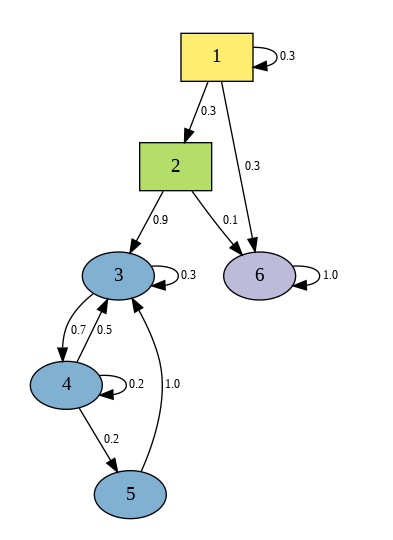


Example 6.1 chain properties:
  is_ergodic:    True
  is_aperiodic:  True
  period:        1
  recurrent:     ['Sunny', 'Cloudy', 'Snowing']
  transient:     []


In [30]:
# ── 6-state textbook matrix (Figure 6.3, p.262) ───────────────────────────
P6 = [
    [1/3, 1/3, 0, 0 , 0, 1/3],
    [0, 0, 9/10, 0, 0, 1/10],
    [0, 0, 1/3, 2/3, 0, 0],
    [0, 0, 1/2, 1/4, 1/4, 0],
    [0, 0, 1, 0, 0, 0],
    [0, 0, 0, 0, 0, 1],
]
s6 = ['1','2','3','4','5','6']
mc6 = MarkovChain(P6, s6)

# ── pydtmc classification (one-line) ─────────────────────────────────────
print('=== 6.4 State Classification (Figure 6.3, p.262) ===')
print(f'  recurrent_states:  {mc6.recurrent_states}')
print(f'  transient_states:  {mc6.transient_states}')
print(f'  absorbing_states:  {mc6.absorbing_states}')
print(f'  is_irreducible:    {mc6.is_irreducible}')
print(f'  is_ergodic:        {mc6.is_ergodic}')
print(f'  period:            {mc6.period}')

print('\n  Textbook: S1,S2 transient; S3,S4,S5 recurrent; S6 absorbing  ✓')

# ── Algebraic verification via reachability matrix P^50 ───────────────────
P6_arr = np.array(P6)
P6_50  = np.linalg.matrix_power(P6_arr, 50)
print('\nReachability matrix (P^50 > 1e-9 = reachable):')
reach = pd.DataFrame(
    (P6_50 > 1e-9).astype(int), index=s6, columns=s6)
print(reach.to_string())

# ── Figure 6.3 — state diagram ────────────────────────────────────────────
print('\nFigure 6.3 — Transition Diagram:')
plot_graph(mc6, dpi=600, )

# ── Also show Example 6.1 chain properties for comparison ─────────────────
mc_ex = MarkovChain([[0.7,0.1,0.2],[0.2,0.7,0.1],[0.5,0.2,0.3]],
                    ['Sunny','Cloudy','Snowing'])
print('\nExample 6.1 chain properties:')
print(f'  is_ergodic:    {mc_ex.is_ergodic}')
print(f'  is_aperiodic:  {mc_ex.is_aperiodic}')
print(f'  period:        {mc_ex.period}')
print(f'  recurrent:     {mc_ex.recurrent_states}')
print(f'  transient:     {mc_ex.transient_states}')